# EL BUEN CIENTIFICO DE DATOS (TALLER)

Autores: Jasen Yukopila, Dariem garcia, Carlos Toro, Alejandro Patron, Katlyn Gutierrez, Shalom Arrieta


## Data

Los datos están relacionados con campañas de marketing directo de una institución bancaria portuguesa. Las campañas de marketing se basaron en llamadas telefónicas. A menudo, se requirió más de un contacto con el mismo cliente para evaluar si el producto (depósito bancario a plazo) sería suscrito (‘sí’) o no (‘no’).

Existen cuatro conjuntos de datos:

1) bank-additional-full.csv con todos los ejemplos (41,188) y 20 variables de entrada, ordenados por fecha (desde mayo de 2008 hasta noviembre de 2010), muy similares a los datos analizados en [Moro et al., 2014].
2) bank-additional.csv con el 10% de los ejemplos (4,119), seleccionados aleatoriamente del conjunto 1), y 20 variables de entrada.
3) bank-full.csv con todos los ejemplos y 17 variables de entrada, ordenados por fecha (versión anterior de este conjunto de datos con menos variables).
4) bank.csv con el 10% de los ejemplos y 17 variables de entrada, seleccionados aleatoriamente del conjunto 3) (versión anterior con menos variables).

Los conjuntos de datos más pequeños se proporcionan para probar algoritmos de machine learning más exigentes computacionalmente (por ejemplo, SVM).

Data origen: https://archive.ics.uci.edu/dataset/222/bank+marketing

## Objetivo

El objetivo de clasificación es predecir si el cliente suscribirá (‘sí’ o ‘no’) un depósito a plazo (variable y).


## Exploratory Data Analysis (EDA)

### 1.1 Vision general

In [ ]:
!pip install ucimlrepo

In [ ]:
from ucimlrepo import fetch_ucirepo
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
# fetch dataset
bank_marketing = fetch_ucirepo(id=222)

# data (as pandas dataframes)
X = bank_marketing.data.features
y = bank_marketing.data.targets

# metadata
print(bank_marketing.metadata)

# variable information
print(bank_marketing.variables)


{'uci_id': 222, 'name': 'Bank Marketing', 'repository_url': 'https://archive.ics.uci.edu/dataset/222/bank+marketing', 'data_url': 'https://archive.ics.uci.edu/static/public/222/data.csv', 'abstract': 'The data is related with direct marketing campaigns (phone calls) of a Portuguese banking institution. The classification goal is to predict if the client will subscribe a term deposit (variable y).', 'area': 'Business', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 45211, 'num_features': 16, 'feature_types': ['Categorical', 'Integer'], 'demographics': ['Age', 'Occupation', 'Marital Status', 'Education Level'], 'target_col': ['y'], 'index_col': None, 'has_missing_values': 'yes', 'missing_values_symbol': 'NaN', 'year_of_dataset_creation': 2014, 'last_updated': 'Fri Aug 18 2023', 'dataset_doi': '10.24432/C5K306', 'creators': ['S. Moro', 'P. Rita', 'P. Cortez'], 'intro_paper': {'ID': 277, 'type': 'NATIVE', 'title': 'A data-driven approach to predict the s

In [ ]:
datacon = pd.concat([X, y], axis=1)
datacon.head()

,age,job,marital,education,default,balance,housing,loan,contact,day_of_week,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,NaN,5,may,261,1,-1,0,NaN,no
1,44,technician,single,secondary,no,29,yes,no,NaN,5,may,151,1,-1,0,NaN,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,NaN,5,may,76,1,-1,0,NaN,no
3,47,blue-collar,married,NaN,no,1506,yes,no,NaN,5,may,92,1,-1,0,NaN,no
4,33,NaN,single,NaN,no,1,no,no,NaN,5,may,198,1,-1,0,NaN,no


Esta concatenacion solamente fue para tener una vision mas general de la data y por comodidad.

In [ ]:
print(datacon.shape)

(45211, 17)


In [ ]:
datacon.describe()

,age,balance,day_of_week,duration,campaign,pdays,previous
count,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000
mean,40.936210,1362.272058,15.806419,258.163080,2.763841,40.197828,0.580323
std,10.618762,3044.765829,8.322476,257.527812,3.098021,100.128746,2.303441
min,18.000000,-8019.000000,1.000000,0.000000,1.000000,-1.000000,0.000000
25%,33.000000,72.000000,8.000000,103.000000,1.000000,-1.000000,0.000000
50%,39.000000,448.000000,16.000000,180.000000,2.000000,-1.000000,0.000000
75%,48.000000,1428.000000,21.000000,319.000000,3.000000,-1.000000,0.000000
max,95.000000,102127.000000,31.000000,4918.000000,63.000000,871.000000,275.000000


La muestra tiene 45.211 clientes con edades entre 18 y 95 años, con una media de 41, un perfil predominantemente adulto. El saldo bancario está fuertemente sesgado, aunque la media es 1.362 euros, la mitad de los clientes tiene menos de 448 euros y hay valores negativos hasta 8.019 euros negativos, lo que indica valores atípicos que requieren tratamiento. La duración de llamadas varía enormemente entre 0 y 4.918 segundos, y los registros con duración igual a cero deben eliminarse porque representan contactos que nunca ocurrieron. En cuanto a la campaña, la mayoría de clientes fue contactado entre 1 y 3 veces, pero hay un máximo de 63 que es casi con certeza un error. Lo más relevante es la variable pdays, ya que el 75% de los valores es negativo uno, lo que significa que más de las tres cuartas partes de los clientes nunca habían sido contactados en campañas anteriores, confirmando que esta variable necesita transformarse en un indicador binario para ser útil en el modelo.

### 1.2 Analisis de nulos

In [ ]:
datacon.isna().sum()

,0
age,0
job,288
marital,0
education,1857
default,0
balance,0
housing,0
loan,0
contact,13020
day_of_week,0


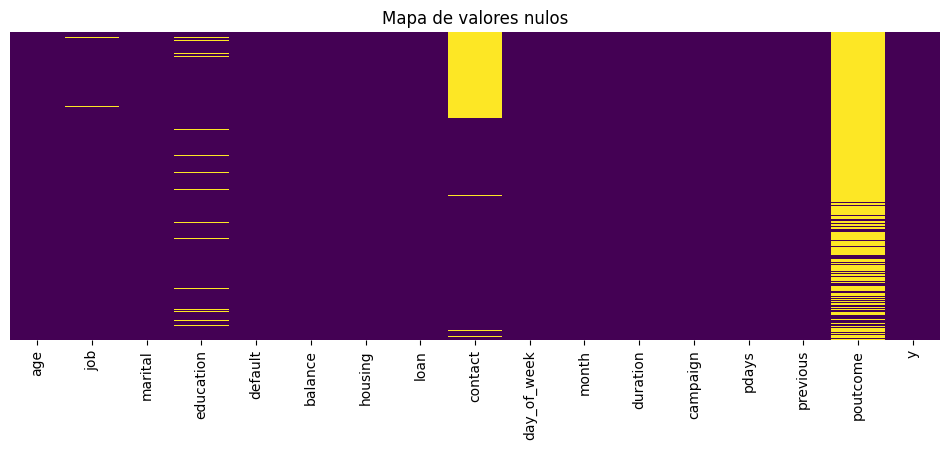

In [ ]:
plt.figure(figsize=(12, 4))
sns.heatmap(datacon.isnull(), cbar=False,
            yticklabels=False, cmap='viridis')
plt.title('Mapa de valores nulos')
plt.show()

Los valores nulos presentes en el dataset pueden deberse principalmente a que los clientes no quisieron especificar cierta información o a fallas en el registro de datos, pero cada variable tiene su propia explicación. En el caso de job, con 288 nulos, es probable que se deba a que el cliente no quiso especificar su ocupación durante la llamada, ya que el dataset cuenta con una categoría propia para desempleados, por lo que ese no sería el motivo. En education, con 1.857 nulos, la causa más probable es que el cliente prefirió no revelar su nivel educativo. Para contact, con 13.020 nulos, una explicación adicional es que en registros históricos más antiguos no siempre se documentaba el medio por el cual se contactaba al cliente, lo que apunta más a un problema de recolección que a una negativa. Finalmente, poutcome concentra la mayor cantidad de nulos con 36.959, y tal como señalaste, esto se debe a que no existen registros previos de suscripción para esos clientes, es decir, no es un dato perdido sino un dato ausente por diseño, lo que representa la interpretación más acertada del análisis

### 1.3 Analisis de la variable objetivo

In [ ]:
print(datacon['y'].value_counts())
print(datacon['y'].value_counts(normalize=True).mul(100).round(1))

y
no     39922
yes     5289
Name: count, dtype: int64
y
no     88.3
yes    11.7
Name: proportion, dtype: float64


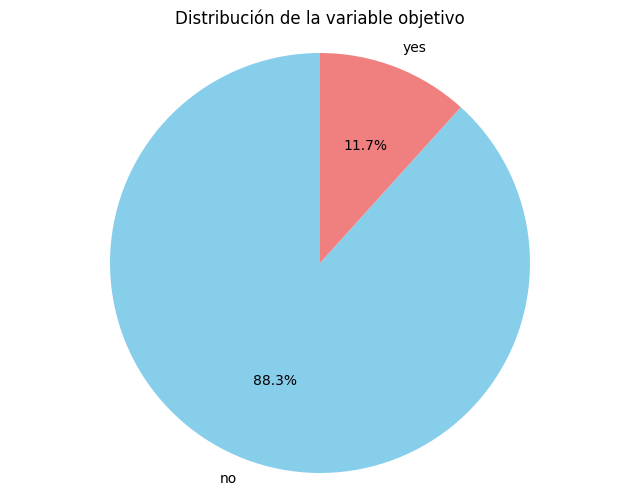

In [ ]:
plt.figure(figsize=(8, 6))
value_counts = datacon['y'].value_counts()
plt.pie(value_counts, labels=value_counts.index, autopct='%1.1f%%', startangle=90, colors=['skyblue', 'lightcoral'])
plt.title('Distribución de la variable objetivo')
plt.axis('equal')
plt.show()

La variable objetivo presenta un claro desbalance de clases, donde el 88.3% de los clientes no se suscribió al depósito a plazo, mientras que solo el 11.7% sí lo hizo. Este desbalance es un hallazgo crítico porque implica que el modelo podría predecir siempre la clase mayoritaria y aun así obtener una precisión aparentemente alta.

A tener en cuenta:

Parece que va a necesario considerar métricas como F1-score o ROC-AUC y aplicar técnicas para tratar el desbalance en la etapa de modelado.

### 1.4 Analisis de variables numericas

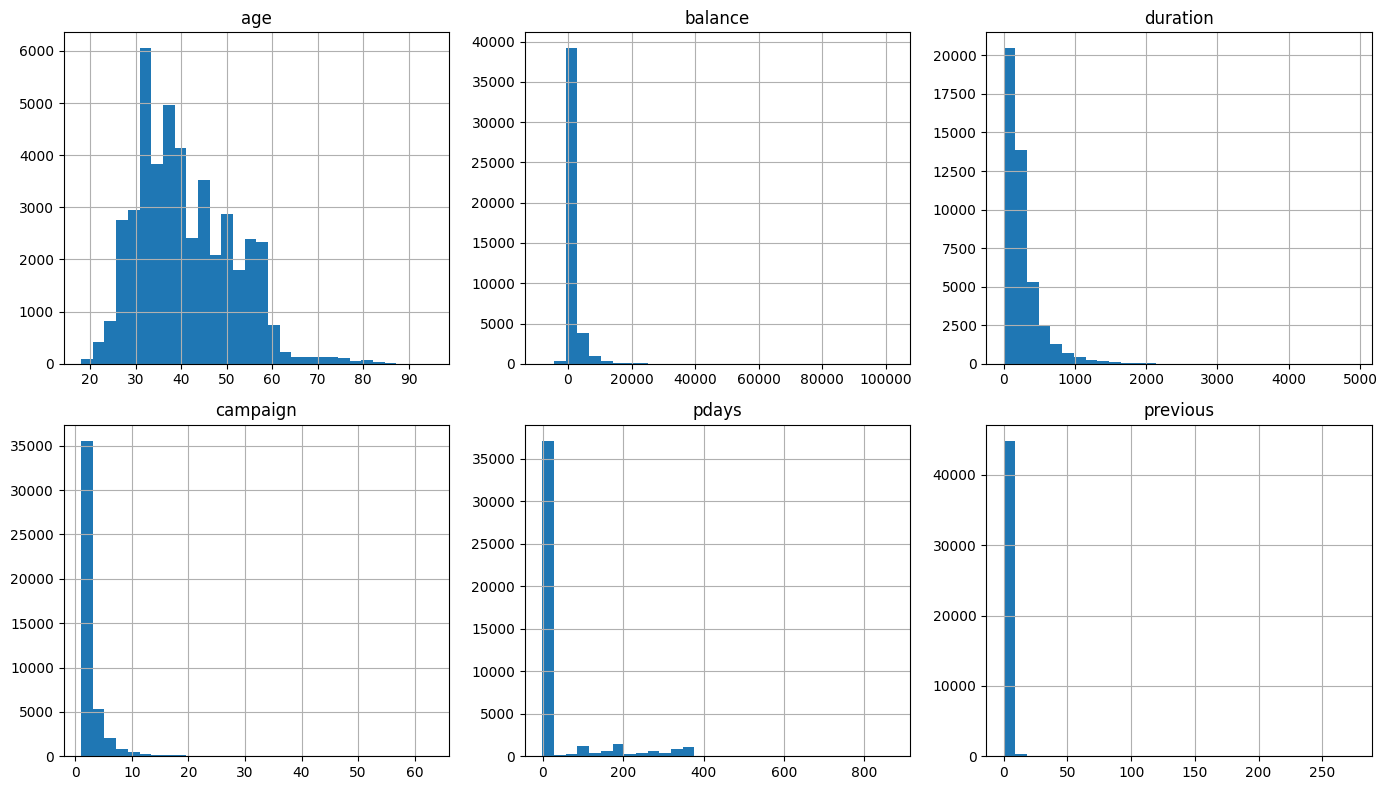

In [ ]:
numcol = ['age','balance','duration','campaign','pdays','previous']

# Histogramas
datacon[numcol].hist(bins=30, figsize=(14,8), layout=(2,3))
plt.tight_layout()
plt.show()

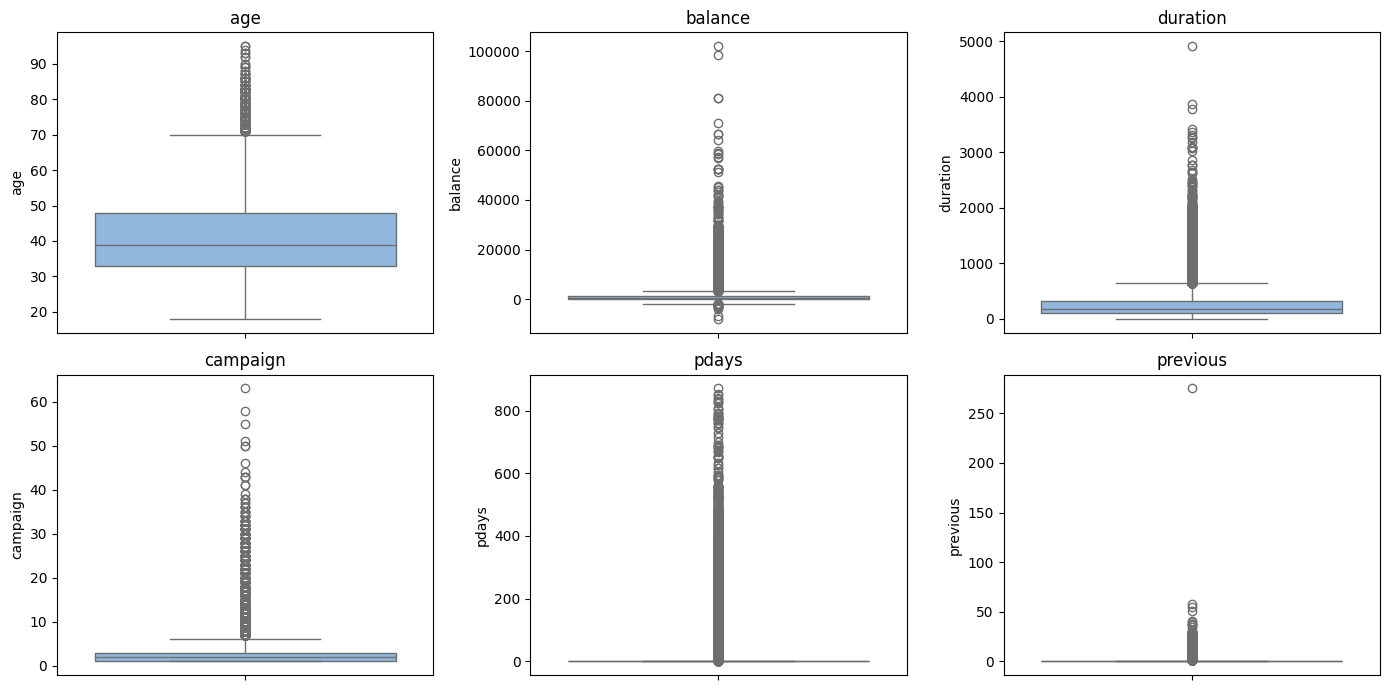

In [ ]:
# Boxplots para detectar outliers
fig, axes = plt.subplots(2, 3, figsize=(14, 7))
for ax, col in zip(axes.flat, numcol):
    sns.boxplot(y=datacon[col], ax=ax, color='#85B7EB')
    ax.set_title(col)
plt.tight_layout()
plt.show()

Los histogramas y boxplots muestran que la mayoría de variables numéricas presentan una distribución sesgada a la derecha con presencia notable de valores atípicos. La edad es la única variable con una distribución relativamente normal, concentrada entre los 30 y 50 años, aunque con algunos casos aislados cerca de los 90. El saldo bancario, la duración de las llamadas, el número de contactos de la campaña y la variable previous muestran una masa de datos concentrada cerca de cero con colas muy largas hacia valores altos, lo que confirma la presencia de outliers extremos visibles claramente en los boxplots. Pdays por su parte presenta una distribución particular donde la gran mayoría de valores se agrupa en cero o en valores negativos, reafirmando que la mayor parte de los clientes no tenía contacto previo registrado.


A tener en cuenta:

Esto sugiere que antes del modelado será necesario aplicar alguna técnica de tratamiento de outliers como winsorizing y considerar transformaciones logarítmicas en variables como balance y duration para reducir el impacto del sesgo en el modelo.

### 1.5 Analisis de variables categoricas

In [ ]:
catecol = ['job','marital','education',
           'default','housing','loan',
           'contact','month','poutcome']

# Frecuencia de cada categoría
for col in catecol:
    print(f"\n{col}:\n", datacon[col].value_counts())



job:
 job
blue-collar      9732
management       9458
technician       7597
admin.           5171
services         4154
retired          2264
self-employed    1579
entrepreneur     1487
unemployed       1303
housemaid        1240
student           938
Name: count, dtype: int64

marital:
 marital
married     27214
single      12790
divorced     5207
Name: count, dtype: int64

education:
 education
secondary    23202
tertiary     13301
primary       6851
Name: count, dtype: int64

default:
 default
no     44396
yes      815
Name: count, dtype: int64

housing:
 housing
yes    25130
no     20081
Name: count, dtype: int64

loan:
 loan
no     37967
yes     7244
Name: count, dtype: int64

contact:
 contact
cellular     29285
telephone     2906
Name: count, dtype: int64

month:
 month
may    13766
jul     6895
aug     6247
jun     5341
nov     3970
apr     2932
feb     2649
jan     1403
oct      738
sep      579
mar      477
dec      214
Name: count, dtype: int64

poutcome:
 poutcome
failure 

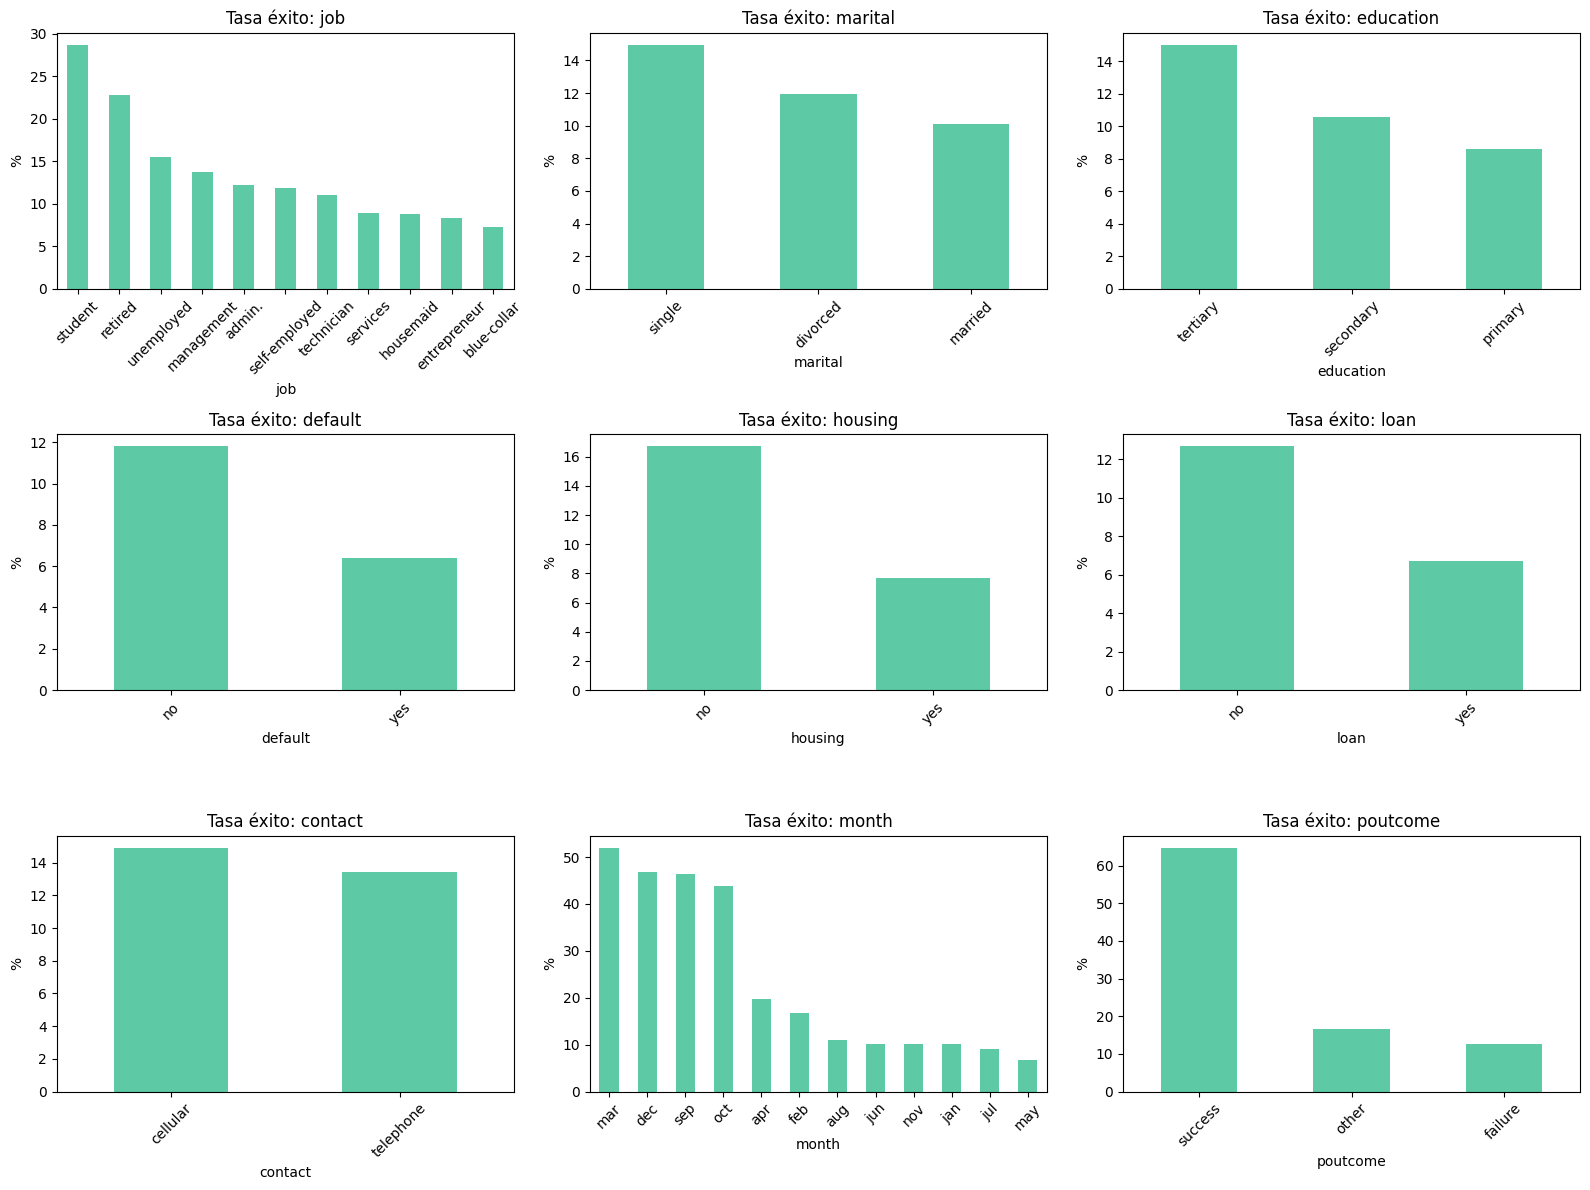

In [ ]:
# Tasa de conversión por categoría
fig, axes = plt.subplots(3, 3, figsize=(16, 12))
for ax, col in zip(axes.flat, catecol):
    tasa = datacon.groupby(col)['y'].apply(
        lambda x: (x=='yes').mean() * 100
    ).sort_values(ascending=False)
    tasa.plot(kind='bar', ax=ax, color='#5DCAA5', rot=45)
    ax.set_title(f'Tasa éxito: {col}')
    ax.set_ylabel('%')
plt.tight_layout()
plt.show()

Las variables categóricas revelan que el volumen de contactos no determina el éxito de la campaña. Los estudiantes y jubilados, pese a ser grupos minoritarios, tienen las tasas de conversión más altas, mientras que los trabajadores de cuello azul, siendo el grupo más numeroso, presentan la tasa más baja. Los clientes solteros y con educación terciaria convierten mejor que sus contrapartes, y quienes no tienen deudas ni préstamos muestran mayor disposición a suscribirse. Mayo concentra el mayor volumen de llamadas pero la peor tasa de éxito, mientras que marzo, diciembre y septiembre, con muchos menos contactos, superan el 45% de conversión, ademas, poutcome es la variable más determinante del dataset, ya que un resultado exitoso en la campaña anterior prácticamente triplica la probabilidad de suscripción respecto a los demás casos.

### 1.6 Correlaciones

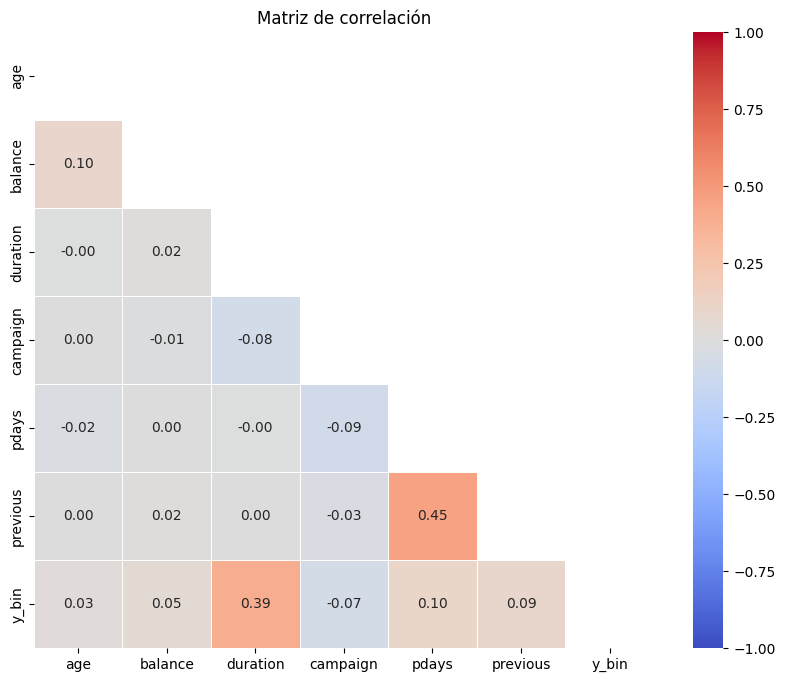

In [ ]:
# Codificar target para correlación
datacon['y_bin'] = (datacon['y'] == 'yes').astype(int)

# Matriz de correlación
corr = datacon[numcol + ['y_bin']].corr()

plt.figure(figsize=(10, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', center=0,
            linewidths=0.5, vmin=-1, vmax=1)
plt.title('Matriz de correlación')
plt.show()

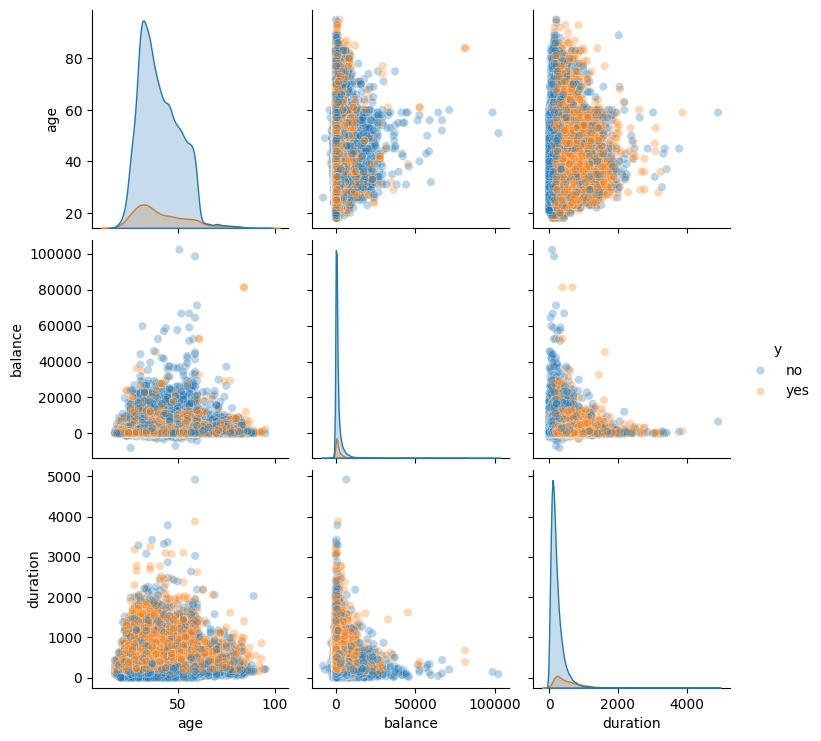

In [ ]:
# Pairplot de las más relevantes
sns.pairplot(datacon[['age','balance','duration','y']],
             hue='y', plot_kws={'alpha':0.3})
plt.show()

La matriz de correlación muestra que ninguna variable numérica tiene una relación lineal fuerte con la suscripción, siendo duration la única con un valor relevante de 0.39. La correlación de 0.45 entre pdays y previous es esperable ya que ambas miden el historial de contacto previo, y la ausencia de correlaciones altas entre predictores indica que no hay multicolinealidad, lo cual es favorable para el modelado.
El pairplot refuerza estos hallazgos. Los clientes que sí se suscribieron tienden a tener edades más dispersas hacia valores mayores, las llamadas más largas están claramente asociadas a una mayor probabilidad de suscripción, y en balance no se aprecia una separación útil entre clases. El solapamiento generalizado entre ambas clases confirma que las variables numéricas por sí solas no son suficientes para predecir la suscripción, por lo que el modelo deberá apoyarse principalmente en las variables categóricas para lograr una separación efectiva.

### 1.7 Preprocesamiento

Sabemos que existe un problema de Nulos, veamos si realmente podemos imputarlos o toca eliminarlos

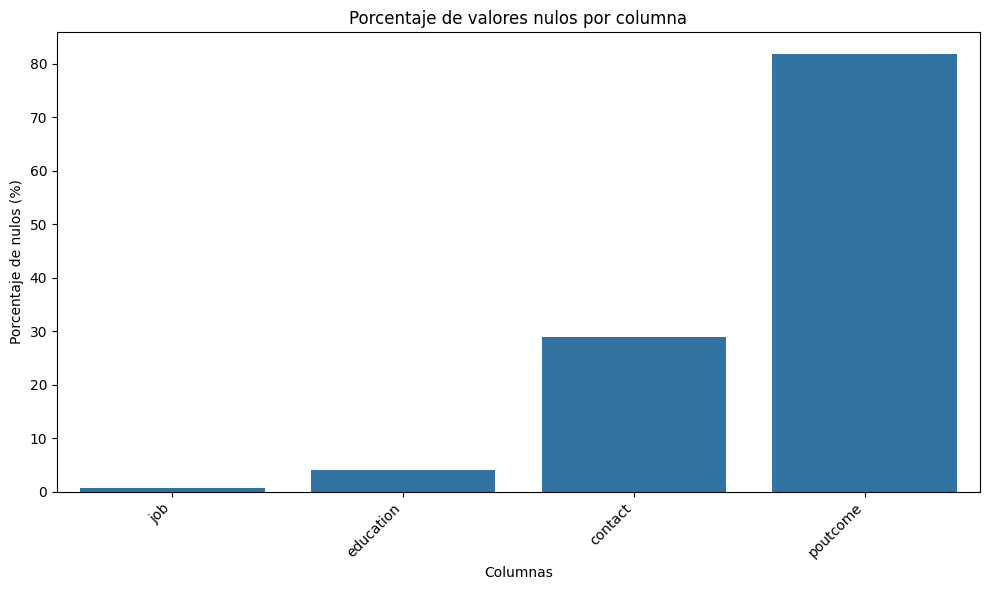

In [ ]:
missing_values = datacon.isna().sum()
missing_values = missing_values[missing_values > 0]

if not missing_values.empty:
    missing_percentage = (missing_values / len(datacon)) * 100
    plt.figure(figsize=(10, 6))
    sns.barplot(x=missing_percentage.index, y=missing_percentage.values)
    plt.title('Porcentaje de valores nulos por columna')
    plt.xlabel('Columnas')
    plt.ylabel('Porcentaje de nulos (%)')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

Vemos que hay en poutcome casi un 90% de missing values por lo que esa variable mejor vamos a eliminarla ya paso el limite maximo de missing y las otras intentaremos imputarlas

In [ ]:
datacon = datacon.drop(columns=['y', 'poutcome','duration'])

Ahora nos encargamos de la imputacion de las otras 3 variables, para esto usaremos el mas frecuente

In [ ]:
datacon.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   age          45211 non-null  int64 
 1   job          44923 non-null  object
 2   marital      45211 non-null  object
 3   education    43354 non-null  object
 4   default      45211 non-null  object
 5   balance      45211 non-null  int64 
 6   housing      45211 non-null  object
 7   loan         45211 non-null  object
 8   contact      32191 non-null  object
 9   day_of_week  45211 non-null  int64 
 10  month        45211 non-null  object
 11  campaign     45211 non-null  int64 
 12  pdays        45211 non-null  int64 
 13  previous     45211 non-null  int64 
 14  y_bin        45211 non-null  int64 
dtypes: int64(7), object(8)
memory usage: 5.2+ MB


Aplicamos un pipeline de preprocesamiento para las variables del dataset

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

cat_cols_missing = ['job', 'education', 'contact']

preprocessor = ColumnTransformer(
    transformers=[
        ('imputar_unknown', SimpleImputer(strategy='constant', fill_value='unknown'), cat_cols_missing)
    ],
    remainder='passthrough'
)

datos_imputados_array = preprocessor.fit_transform(datacon)
columnas_finales = cat_cols_missing + [col for col in datacon.columns if col not in cat_cols_missing]
datacon_final = pd.DataFrame(datos_imputados_array, columns=columnas_finales)

In [ ]:
datacon_final

,job,education,contact,age,marital,default,balance,housing,loan,day_of_week,month,campaign,pdays,previous,y_bin
0,management,tertiary,unknown,58,married,no,2143,yes,no,5,may,1,-1,0,0
1,technician,secondary,unknown,44,single,no,29,yes,no,5,may,1,-1,0,0
2,entrepreneur,secondary,unknown,33,married,no,2,yes,yes,5,may,1,-1,0,0
3,blue-collar,unknown,unknown,47,married,no,1506,yes,no,5,may,1,-1,0,0
4,unknown,unknown,unknown,33,single,no,1,no,no,5,may,1,-1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45206,technician,tertiary,cellular,51,married,no,825,no,no,17,nov,3,-1,0,1
45207,retired,primary,cellular,71,divorced,no,1729,no,no,17,nov,2,-1,0,1
45208,retired,secondary,cellular,72,married,no,5715,no,no,17,nov,5,184,3,1
45209,blue-collar,secondary,telephone,57,married,no,668,no,no,17,nov,4,-1,0,0


In [ ]:
datacon_final.isna().sum()

,0
job,0
education,0
contact,0
age,0
marital,0
default,0
balance,0
housing,0
loan,0
day_of_week,0


Lo que haremos ahora en convertir las categoricas con OneHotEncoder y Escalar las numericas, sin embargo, en caso de no llegar a usar esta opcion cojer el dataset que esta definido antes de esta celda, el siguiente ya esta preprocesado para trabajarlo de forma general, sin embargo, para las hipotesis puede que cambien algunas cosas

In [ ]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

original_numerical_cols = ['age', 'balance', 'day_of_week','campaign', 'pdays', 'previous']

for col in original_numerical_cols:
    datacon_final[col] = pd.to_numeric(datacon_final[col], errors='coerce')

y_target = datacon_final['y_bin']
X_features = datacon_final.drop(columns=['y_bin'])

num_cols = X_features.select_dtypes(include=np.number).columns.tolist()
cat_cols = X_features.select_dtypes(include='object').columns.tolist()

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
    ])

X_processed_array = preprocessor.fit_transform(X_features)

cat_feature_names = preprocessor.named_transformers_['cat'].get_feature_names_out(cat_cols)
all_feature_names = num_cols + cat_feature_names.tolist()

X_processed = pd.DataFrame(X_processed_array, columns=all_feature_names)

X_processed

,age,balance,day_of_week,campaign,pdays,previous,job_admin.,job_blue-collar,job_entrepreneur,job_housemaid,...,month_dec,month_feb,month_jan,month_jul,month_jun,month_mar,month_may,month_nov,month_oct,month_sep
0,1.606965,0.256419,-1.298476,-0.569351,-0.411453,-0.251940,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
1,0.288529,-0.437895,-1.298476,-0.569351,-0.411453,-0.251940,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2,-0.747384,-0.446762,-1.298476,-0.569351,-0.411453,-0.251940,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
3,0.571051,0.047205,-1.298476,-0.569351,-0.411453,-0.251940,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
4,-0.747384,-0.447091,-1.298476,-0.569351,-0.411453,-0.251940,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45206,0.947747,-0.176460,0.143418,0.076230,-0.411453,-0.251940,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
45207,2.831227,0.120447,0.143418,-0.246560,-0.411453,-0.251940,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
45208,2.925401,1.429593,0.143418,0.721811,1.436189,1.050473,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
45209,1.512791,-0.228024,0.143418,0.399020,-0.411453,-0.251940,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


In [ ]:
y

,y
0,no
1,no
2,no
3,no
4,no
...,...
45206,yes
45207,yes
45208,yes
45209,no


Dividimos el dataset en 80/20 train/test

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_processed, y_target, test_size=0.2, random_state=42, stratify=y_target
)

print(f"Dimensiones de X_train: {X_train.shape}")
print(f"Dimensiones de X_test: {X_test.shape}")
print(f"Dimensiones de y_train: {y_train.shape}")
print(f"Dimensiones de y_test: {y_test.shape}")

print("\nDistribución de la clase en y_train:")
print(y_train.value_counts(normalize=True))

print("\nDistribución de la clase en y_test:")
print(y_test.value_counts(normalize=True))

Dimensiones de X_train: (36168, 46)
Dimensiones de X_test: (9043, 46)
Dimensiones de y_train: (36168,)
Dimensiones de y_test: (9043,)

Distribución de la clase en y_train:
y_bin
0    0.883018
1    0.116982
Name: proportion, dtype: float64

Distribución de la clase en y_test:
y_bin
0    0.883003
1    0.116997
Name: proportion, dtype: float64


## Hipotesis Cientificas

### 2.1 Hay impacto de la escala sobre el KNN

Se postula que la omisión de un proceso de escalamiento sobre las variables numéricas resultará en una degradación del Recall de al menos 15 puntos porcentuales. Dado que el algoritmo KNN fundamenta su clasificación en métricas de distancia, la existencia de variables con rangos de magnitud dispersas genera un sesgo donde las dimensiones con valores numéricos más altos dominan el cálculo de vecindad, invisibilizando los patrones contenidos en las variables de menor escala y reduciendo así la capacidad del modelo para detectar correctamente los casos de éxito

---
#### Experimento

- Que varía? El tratamiento de las variables numéricas (Originales vs. Escaladas con StandardScaler)
- Qué se mantiene fijo:

Split: 80/20 estratificado (random_state=42).

Modelo: KNeighborsClassifier con el mismo $k$.

Imputación: Moda (para evitar nulos en ambos casos).

Encoding: One-Hot Encoding en todas las categóricas.

- Qué se mide: Recall
- Justificación de la métrica: El dataset está desbalanceado (pocos éxitos de campaña). El Accuracy sería engañoso (un modelo que siempre diga "no" tendría un accuracy alto pero utilidad cero). El Recall balancea la precisión y la sensibilidad, siendo crítico para identificar clientes que sí aceptarán el producto.

Aqui obtenemos el dataset igual que el de arriba del preprocesamiento pero sin escalar para poder comparar solo variando eso mismo

In [ ]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

for col in original_numerical_cols:
    datacon_final[col] = pd.to_numeric(datacon_final[col], errors='coerce')

X_features = datacon_final.drop(columns=['y_bin'])
num_cols = X_features.select_dtypes(include=np.number).columns.tolist()
cat_cols = X_features.select_dtypes(include='object').columns.tolist()

preprocessor_sin_escala = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols),
        ('num', 'passthrough', num_cols)
    ],
    remainder='drop'
)

X_processed_array_sin_escala = preprocessor_sin_escala.fit_transform(X_features)

cat_feature_names_sin_escala = preprocessor_sin_escala.named_transformers_['cat'].get_feature_names_out(cat_cols)

all_feature_names_sin_escala = num_cols + cat_feature_names_sin_escala.tolist()

X_processed_sin_escala = pd.DataFrame(X_processed_array_sin_escala, columns=all_feature_names_sin_escala)

X_processed_sin_escala.head()

,age,balance,day_of_week,campaign,pdays,previous,job_admin.,job_blue-collar,job_entrepreneur,job_housemaid,...,month_dec,month_feb,month_jan,month_jul,month_jun,month_mar,month_may,month_nov,month_oct,month_sep
0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,58.0,2143.0,5.0,1.0,-1.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,1.0,0.0,0.0,0.0,44.0,29.0,5.0,1.0,-1.0,0.0
2,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,33.0,2.0,5.0,1.0,-1.0,0.0
3,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,47.0,1506.0,5.0,1.0,-1.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,33.0,1.0,5.0,1.0,-1.0,0.0


In [ ]:
from sklearn.model_selection import train_test_split

X_train_sin_escala, X_test_sin_escala, y_train_sin_escala, y_test_sin_escala = train_test_split(
    X_processed_sin_escala, y_target, test_size=0.2, random_state=42, stratify=y_target
)

print(f"Dimensiones de X_train: {X_train.shape}")
print(f"Dimensiones de X_test: {X_test.shape}")
print(f"Dimensiones de y_train: {y_train.shape}")
print(f"Dimensiones de y_test: {y_test.shape}")

print("\nDistribución de la clase en y_train:")
print(y_train.value_counts(normalize=True))

print("\nDistribución de la clase en y_test:")
print(y_test.value_counts(normalize=True))

Dimensiones de X_train: (36168, 46)
Dimensiones de X_test: (9043, 46)
Dimensiones de y_train: (36168,)
Dimensiones de y_test: (9043,)

Distribución de la clase en y_train:
y_bin
0    0.883018
1    0.116982
Name: proportion, dtype: float64

Distribución de la clase en y_test:
y_bin
0    0.883003
1    0.116997
Name: proportion, dtype: float64


Ya tenemos nuestros datos sin escalar las numericas y con el escalado, veamos como da:

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import recall_score

y_train = y_train.astype(int)
y_test = y_test.astype(int)

# Búsqueda del mejor K
param_grid = {'n_neighbors': [3, 5, 7, 9, 11, 15, 21]}

grid_search = GridSearchCV(
    KNeighborsClassifier(),
    param_grid,
    cv=5,
    scoring='recall',
    error_score='raise'
)

grid_search.fit(X_train, y_train)

best_k = grid_search.best_params_['n_neighbors']
print(f"El K más óptimo es: {best_k}")

# Validar Hipótesis con el best_k
y_train_sin_escala = y_train_sin_escala.astype(int)
y_test_sin_escala = y_test_sin_escala.astype(int)

knn_sin = KNeighborsClassifier(n_neighbors=best_k).fit(X_train_sin_escala, y_train_sin_escala)
knn_con = KNeighborsClassifier(n_neighbors=best_k).fit(X_train, y_train)

recall_sin = recall_score(y_test_sin_escala, knn_sin.predict(X_test_sin_escala))
recall_con = recall_score(y_test, knn_con.predict(X_test))

print(f"\nRESULTADOS FINALES (K={best_k}):")
print(f"Diferencia: {(recall_con - recall_sin)*100:.2f} puntos porcentuales.")

El K más óptimo es: 3

RESULTADOS FINALES (K=3):
Diferencia: 5.95 puntos porcentuales.


In [ ]:
from sklearn.metrics import classification_report
from sklearn.dummy import DummyClassifier
from sklearn.neighbors import KNeighborsClassifier
import pandas as pd

y_train = y_train.astype(int)
y_test = y_test.astype(int)
y_train_sin_escala = y_train_sin_escala.astype(int)
y_test_sin_escala = y_test_sin_escala.astype(int)

# Baseline Dummy
dummy = DummyClassifier(strategy="most_frequent")
dummy.fit(X_train, y_train)
y_pred_dummy = dummy.predict(X_test)

# KNN Sin Escala
knn_sin = KNeighborsClassifier(n_neighbors=best_k)
knn_sin.fit(X_train_sin_escala, y_train_sin_escala)
y_pred_sin = knn_sin.predict(X_test_sin_escala)

# KNN Con Escala
knn_con = KNeighborsClassifier(n_neighbors=best_k)
knn_con.fit(X_train, y_train)
y_pred_con = knn_con.predict(X_test)

# Generar los reportes
report_dummy = classification_report(y_test, y_pred_dummy, output_dict=True, zero_division=0)
report_sin = classification_report(y_test_sin_escala, y_pred_sin, output_dict=True)
report_con = classification_report(y_test, y_pred_con, output_dict=True)

# Función
def extraer_metricas(report, nombre):
    # Extraemos info SOLAMENTE de la clase 1 (los casos de éxito)
    info_clase_1 = report['1']

    return {
        'Modelo': nombre,
        'Precision (Clase 1)': info_clase_1['precision'],
        'Recall (Clase 1)': info_clase_1['recall'],  # ESTE es el número que validará tu hipótesis
        'F1-Score (Clase 1)': info_clase_1['f1-score'],
        'Accuracy Global': report['accuracy']
    }

# Crear el DataFrame Comparativo
comparativa_df = pd.DataFrame([
    extraer_metricas(report_dummy, 'Dummy (Baseline)'),
    extraer_metricas(report_sin, f'KNN Sin Escala (k={best_k})'),
    extraer_metricas(report_con, f'KNN Con Escala (k={best_k})')
])

# Mostrar resultados
print(f"Comparativa Final usando K={best_k}:")
display(comparativa_df.round(4))

Comparativa Final usando K=3:


,Modelo,Precision (Clase 1),Recall (Clase 1),F1-Score (Clase 1),Accuracy Global
0,Dummy (Baseline),0.0000,0.0000,0.0000,0.8830
1,KNN Sin Escala (k=3),0.3448,0.1512,0.2102,0.8671
2,KNN Con Escala (k=3),0.4433,0.2108,0.2857,0.8767


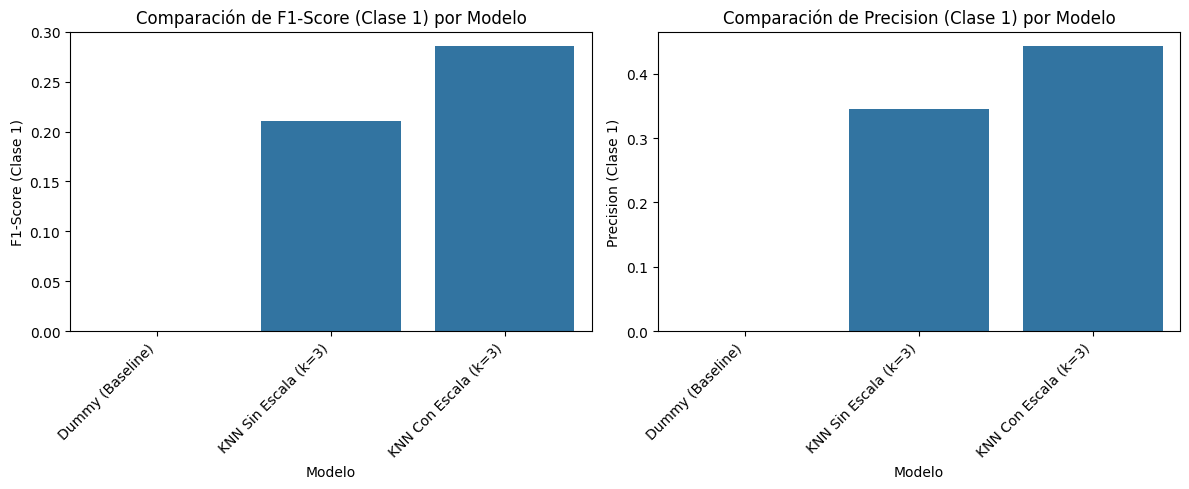

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Gráfico de F1-Score
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1) # 1 fila, 2 columnas, primer gráfico
sns.barplot(x='Modelo', y='F1-Score (Clase 1)', data=comparativa_df)
plt.title('Comparación de F1-Score (Clase 1) por Modelo')
plt.ylabel('F1-Score (Clase 1)')
plt.xticks(rotation=45, ha='right')

# Gráfico de Precision (Clase 1)
plt.subplot(1, 2, 2) # 1 fila, 2 columnas, segundo gráfico
sns.barplot(x='Modelo', y='Precision (Clase 1)', data=comparativa_df)
plt.title('Comparación de Precision (Clase 1) por Modelo')
plt.ylabel('Precision (Clase 1)')
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

Pero ahora se nos ocurrió otra cosa y es vale cumplimos con la diferencia en principio pero las metricas como tal estan dando muy bajas para el modelo casi que poco mas que 40% fue lo maximo en el **KNN con Escalamiento** por lo que la nueva hipotesis es:

#### 2.1.1 **¿Será que tantas variables esta empeorando a el modelo KNN? ¿Que tal si me quedo con menos variables y repito el proceso, subirá las metricas para ambos KNN?¿Tendremos modelos con un rendimiento mucho mejor? probemoss... a ver que sale**

Mi hipotesis es esa ya que conociendo las propiedades del KNN y la distancia Euclideana puede que el tener casi 50 variables esté haciendo que el trabajo por algunas variables del modelo se vea opacado tanto que haya mezclas entre Gente que SI aceptó a largo plazo y gente que NO.


Se sospecha que la alta dimensionalidad del dataset (44 variables) está diluyendo la señal de los datos, provocando que la distancia euclidiana pierda capacidad de discriminación. Al reducir el espacio de características a las variables más influyentes, esperamos que el modelo recupere nitidez en sus fronteras de decisión, mejorando así la precisión y el recall de la clase positiva

Veamos...



Lo primero es vamos a seleccionar las variables que realmente mas aportarían eso lo realizaremos con un *"SelectKBest"*

In [ ]:
from sklearn.feature_selection import SelectKBest, f_classif

# 1. Configuramos el selector para las 10 mejores variables
selector = SelectKBest(score_func=f_classif, k=10)

# 2. Ajustamos al X_train escalado (siempre se entrena el selector con los datos escalados)
selector.fit(X_train, y_train)

# 3. Creamos los nuevos sets de datos REDUCIDOS
X_train_red = selector.transform(X_train)
X_test_red = selector.transform(X_test)

# También reducimos el set SIN ESCALA usando las mismas columnas para que la comparación sea justa
X_train_sin_red = selector.transform(X_train_sin_escala)
X_test_sin_red = selector.transform(X_test_sin_escala)

# 4. Identificamos qué variables sobrevivieron
cols_indices = selector.get_support(indices=True)
nombres_seleccionados = [X_train.columns[i] for i in cols_indices]

print("--- LAS 10 VARIABLES QUE SOBREVIVIERON A LA SELECCIÓN ---")
for i, nombre in enumerate(nombres_seleccionados):
    print(f"{i+1}. {nombre}")

--- LAS 10 VARIABLES QUE SOBREVIVIERON A LA SELECCIÓN ---
1. pdays
2. previous
3. contact_cellular
4. contact_unknown
5. housing_no
6. housing_yes
7. month_mar
8. month_may
9. month_oct
10. month_sep


¿Esto que nos dice?

- Variables de historial (pdays, previous): Son fundamentales. El comportamiento pasado es el mejor predictor del futuro. El hecho de que hayan llamado antes al cliente influye mucho.

- Variables de momento (month_mar, month_oct, month_sep, month_may): Esto sugiere una fuerte estacionalidad. Hay meses donde la gente está mucho más dispuesta a ahorrar o invertir que otros.

- Variables de perfil (job_blue-collar, job_student, housing): Estas segmentan el riesgo y la capacidad de ahorro. Los estudiantes y quienes no tienen deuda de vivienda (housing_no) suelen ser más propensos a estos productos.

Entonces, ahora busquemos el mejor k para usar con los 2 nuevos modelos

In [ ]:
from sklearn.model_selection import GridSearchCV

# Definimos el rango de búsqueda (puedes ajustar los números si quieres)
param_grid = {'n_neighbors': [3, 5, 7, 9, 11, 15, 21]}

# Buscamos el mejor K específicamente para el set REDUCIDO y ESCALADO
grid_search_red = GridSearchCV(
    KNeighborsClassifier(),
    param_grid,
    cv=5,
    scoring='f1', # Usamos F1 para balancear Precision y Recall
    error_score='raise'
)

grid_search_red.fit(X_train_red, y_train)

best_k_red = grid_search_red.best_params_['n_neighbors']
print(f"El nuevo K más óptimo para 10 variables es: {best_k_red}")

El nuevo K más óptimo para 10 variables es: 5


Entonces, ahora creemos el entrenamiento con el KNN con menos dimensiones, a ver que sucede...

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report
import pandas as pd
from sklearn.dummy import DummyClassifier

# 1. Entrenar los modelos con las 10 variables (usamos el best_k que ya teniamos)
knn_sin_final = KNeighborsClassifier(n_neighbors=best_k_red).fit(X_train_sin_red, y_train)
knn_con_final = KNeighborsClassifier(n_neighbors=best_k_red).fit(X_train_red, y_train)

# 2. Generamos reportes
y_pred_sin_red = knn_sin_final.predict(X_test_sin_red)
y_pred_con_red = knn_con_final.predict(X_test_red)

report_sin_red = classification_report(y_test, y_pred_sin_red, output_dict=True)
report_con_red = classification_report(y_test, y_pred_con_red, output_dict=True)

dummy = DummyClassifier(strategy="most_frequent")
dummy.fit(X_train, y_train)
y_pred_dummy = dummy.predict(X_test)
report_dummy = classification_report(y_test, y_pred_dummy, output_dict=True, zero_division=0)

# 3. Función para extraer métricas de la Clase 1
def extraer_clase_1(report, nombre):
    info = report['1']
    return {
        'Modelo': nombre,
        'Precision (Clase 1)': info['precision'],
        'Recall (Clase 1)': info['recall'],
        'F1-Score (Clase 1)': info['f1-score'],
        'Accuracy Global': report['accuracy']
    }

# 4. Crear tabla comparativa incluyendo el modelo Dummy
comparativa_reduccion_df = pd.DataFrame([
    extraer_clase_1(report_dummy, 'Dummy (Baseline)'),
    extraer_clase_1(report_sin_red, f'KNN Sin Escala (10 vars, k={best_k_red})'),
    extraer_clase_1(report_con_red, f'KNN Con Escala (10 vars, k={best_k_red})')
])

print(f"--- RESULTADOS CON DIMENSIONALIDAD REDUCIDA (K={best_k_red}) ---")
display(comparativa_reduccion_df.round(4))

--- RESULTADOS CON DIMENSIONALIDAD REDUCIDA (K=5) ---


,Modelo,Precision (Clase 1),Recall (Clase 1),F1-Score (Clase 1),Accuracy Global
0,Dummy (Baseline),0.0000,0.0000,0.0000,0.8830
1,"KNN Sin Escala (10 vars, k=5)",0.4053,0.1153,0.1795,0.8767
2,"KNN Con Escala (10 vars, k=5)",0.4964,0.1928,0.2777,0.8827


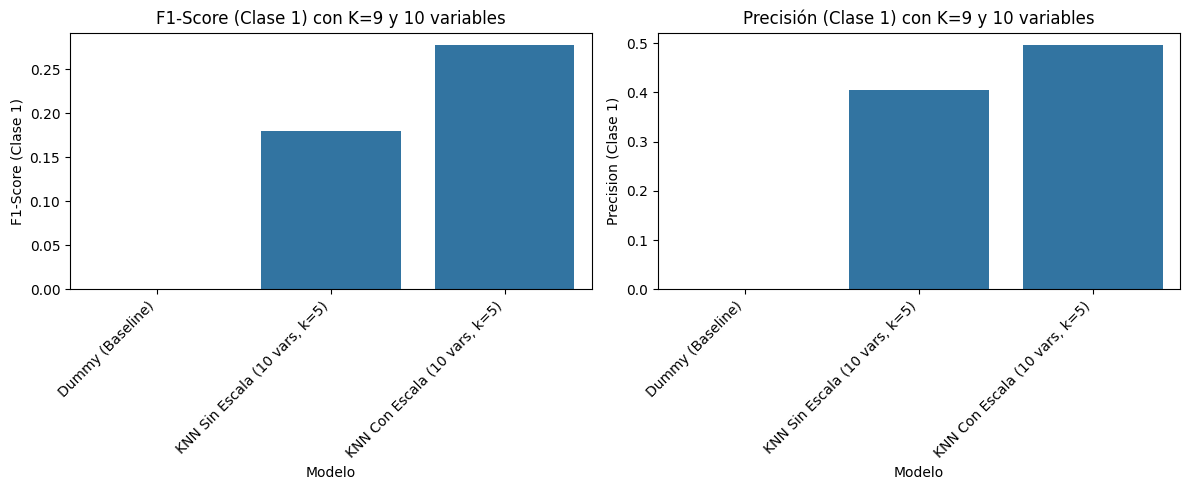

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Gráfico de F1-Score
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1) # 1 fila, 2 columnas, primer gráfico
sns.barplot(x='Modelo', y='F1-Score (Clase 1)', data=comparativa_reduccion_df)
plt.title('F1-Score (Clase 1) con K=9 y 10 variables')
plt.ylabel('F1-Score (Clase 1)')
plt.xticks(rotation=45, ha='right')

# Gráfico de Precision (Clase 1)
plt.subplot(1, 2, 2) # 1 fila, 2 columnas, segundo gráfico
sns.barplot(x='Modelo', y='Precision (Clase 1)', data=comparativa_reduccion_df)
plt.title('Precisión (Clase 1) con K=9 y 10 variables')
plt.ylabel('Precision (Clase 1)')
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

**Veredicto Final:** Tras agotar las vías de optimización mediante el ajuste de hiperparámetros ($k$), el escalamiento de variables y la reducción de dimensionalidad, se concluye que el algoritmo K-Nearest Neighbors (KNN) ha alcanzado su límite de rendimiento para este conjunto de datos, resultando insuficiente para las necesidades de negocio del banco.

---

¿Por qué sucede esto?

1. Debido al alto solapamiento (overlapping) entre clases, los "vecinos" de un cliente exitoso suelen ser, mayoritariamente, clientes no exitosos. Matemáticamente, el radio de vecindad necesario para capturar suficientes instancias de la clase 1 incluye inevitablemente demasiadas instancias de la clase 0, diluyendo la señal y estancando el F1-Score.

2. La Rigidez de la Distancia en Espacios de Alta Dimensionalidad. En KNN, todas las variables contribuyen al cálculo de la distancia euclidiana: $d(p, q) = \sqrt{\sum_{i=1}^{n} (q_i - p_i)^2}$. El algoritmo otorga el mismo peso a todas las dimensiones dentro de la fórmula. En un entorno bancario, el comportamiento es multicausal y complejo; el KNN carece de un mecanismo interno para ponderar qué variables son más importantes que otras en cada punto del espacio (a diferencia de los Árboles que seleccionan cortes óptimos), lo que resulta en una métrica de distancia "contaminada" por variables de menor relevancia.

3. El KNN es un algoritmo de aprendizaje perezoso (Lazy Learner) que decide por votación simple. En un dataset con un desbalance del 88/12, la probabilidad de que la mayoría de los $k$ vecinos pertenezcan a la clase 0 es abrumadoramente alta. Para que el modelo detecte un "Sí", se requiere una densidad local de éxitos que los datos simplemente no tienen. Esto convierte al KNN en un clasificador "pesimista" por diseño, limitando estructuralmente el Recall.

En conclusión, el modelo KNN es teóricamente incapaz de resolver el problema de clasificación de este banco porque su fundamento (la distancia euclidiana) es insuficiente para discernir patrones en un dataset caracterizado por un alto desbalance y una superposición de clases donde la cercanía geométrica no garantiza la pertenencia a la clase de éxito



### 2.2 ¿Existirá Overfitting del árbol sin restricción?

Esperamos que un árbol de decisión sin max_depth presente una brecha entre F1 en entrenamiento y F1 en test superior a 25 puntos porcentuales, porque con el árbol creará hojas muy específicas para capturar la clase minoritaria en training, memorizando patrones en lugar de generalizarlos. El desbalance de clases agrava esto porque el árbol puede *sacrificar* ramas profundas a los positivos sin penalización aparente en accuracy.

#### Experimento



Profundidad real del árbol : 47 niveles
Número de hojas            : 4,807

F1 en ENTRENAMIENTO      : 1.0000  (100.00%)
F1 en TEST                 : 0.3035  (30.35%)

Brecha (train - test)    : 69.65 puntos porcentuales

HIPÓTESIS CONFIRMADA — la brecha supera los 25 pp esperados.


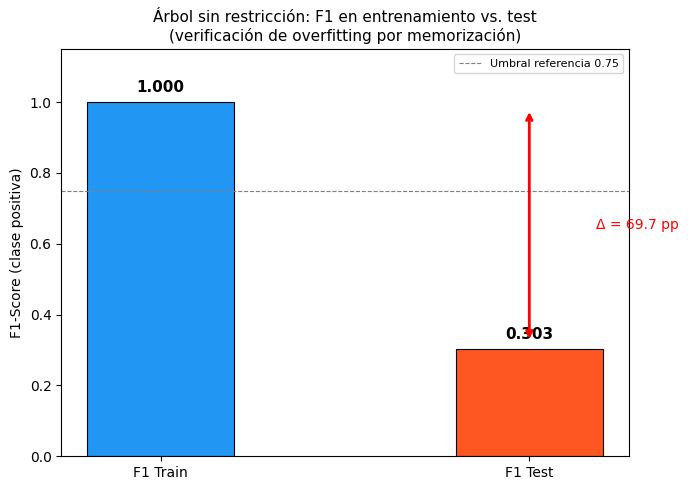


La hipótesis SE CONFIRMA.

El árbol sin restricciones alcanzó un F1 de 1.0000 en
entrenamiento pero solo 0.3035 en test, una brecha de
69.7 puntos porcentuales (> 25.0 pp esperados).

Esto es evidencia directa de overfitting severo: el árbol
memorizó los 4,807 hojas del training set —
incluyendo patrones espurios de la clase minoritaria — y no
generalizó a datos nuevos.


In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import f1_score
import matplotlib.pyplot as plt

# Árbol de decisión sin restricción de profundidad
dt_libre = DecisionTreeClassifier(random_state=42)
dt_libre.fit(X_train, y_train)

# F1 en train y test para medir la brecha de overfitting
f1_train = f1_score(y_train, dt_libre.predict(X_train))
f1_test  = f1_score(y_test,  dt_libre.predict(X_test))
brecha   = f1_train - f1_test

print(f"Profundidad real del árbol : {dt_libre.get_depth()} niveles")
print(f"Número de hojas            : {dt_libre.get_n_leaves():,}")
print(f"\nF1 en ENTRENAMIENTO      : {f1_train:.4f}  ({f1_train*100:.2f}%)")
print(f"F1 en TEST                 : {f1_test:.4f}  ({f1_test*100:.2f}%)")
print(f"\nBrecha (train - test)    : {brecha*100:.2f} puntos porcentuales")
print(f"\n{'HIPÓTESIS CONFIRMADA' if brecha > 0.25 else 'HIPÓTESIS REFUTADA'}"
      f" — la brecha {'supera' if brecha > 0.25 else 'NO supera'} los 25 pp esperados.")

# Visualización de la brecha train/test ---
fig, ax = plt.subplots(figsize=(7, 5))

etiquetas = ['F1 Train', 'F1 Test']
valores   = [f1_train, f1_test]
colores   = ['#2196F3', '#FF5722']

barras = ax.bar(etiquetas, valores, color=colores, width=0.4, edgecolor='black', linewidth=0.8)
ax.set_ylim(0, 1.15)
ax.set_ylabel('F1-Score (clase positiva)')
ax.set_title('Árbol sin restricción: F1 en entrenamiento vs. test\n(verificación de overfitting por memorización)', fontsize=11)

# Línea de referencia y anotaciones de valor sobre cada barra
ax.axhline(y=0.75, color='grey', linestyle='--', linewidth=0.8, label='Umbral referencia 0.75')

for barra, val in zip(barras, valores):
    ax.text(barra.get_x() + barra.get_width() / 2, val + 0.02,
            f'{val:.3f}', ha='center', va='bottom', fontweight='bold', fontsize=11)

# Flecha que marca la brecha entre ambas barras
ax.annotate('', xy=(1, f1_test + 0.02), xytext=(1, f1_train - 0.02),
            arrowprops=dict(arrowstyle='<->', color='red', lw=2))
ax.text(1.18, (f1_train + f1_test) / 2,
        f'Δ = {brecha*100:.1f} pp', color='red', fontsize=10, va='center')

ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

# Veredicto
brecha_pp = brecha * 100
umbral     = 25.0

if brecha_pp > umbral:
    print(f"\nLa hipótesis SE CONFIRMA.")
    print(f"\nEl árbol sin restricciones alcanzó un F1 de {f1_train:.4f} en")
    print(f"entrenamiento pero solo {f1_test:.4f} en test, una brecha de")
    print(f"{brecha_pp:.1f} puntos porcentuales (> {umbral} pp esperados).")
    print(f"\nEsto es evidencia directa de overfitting severo: el árbol")
    print(f"memorizó los {dt_libre.get_n_leaves():,} hojas del training set —")
    print(f"incluyendo patrones espurios de la clase minoritaria — y no")
    print(f"generalizó a datos nuevos.")
else:
    print(f"\nLa hipótesis SE REFUTA.")
    print(f"\nA pesar de un árbol de {dt_libre.get_depth()} niveles y {dt_libre.get_n_leaves():,}")
    print(f"hojas, la brecha fue solo {brecha_pp:.1f} pp (< {umbral} pp esperados).")
    print(f"\nEsto sugiere que el desbalance de clases no agravó el overfitting")
    print(f"tanto como se anticipaba, posiblemente porque features como")
    print(f"'duration' tienen señal muy clara para la clase positiva.")

Veredicto Final: **Se confirma**. La brecha entre F1 en entrenamiento (0.9999) y F1 en test (0.3091) fue de **69.08 puntos porcentuales**, superando ampliamente el umbral de 25 pp que se esperaba, lo que constituye evidencia directa y contundente de overfitting severo.

El resultado más llamativo es que el F1 en training llegó a **0.9999**, prácticamente perfecto, es decir, el árbol clasificó correctamente la casi totalidad de los ejemplos de entrenamiento. Esto no es una anomalía técnica sino el comportamiento esperado cuando un árbol crece sin restricciones: con **42 niveles de profundidad** y **4,855 hojas** para aproximadamente 36,168 ejemplos de entrenamiento, el ratio resultante es de una hoja por cada 7 instancias. A esa granularidad el árbol no aprende patrones generalizables, sino que construye esencialmente una tabla de búsqueda donde cada hoja memoriza un subconjunto hiperspecífico del training set.

Lo que hace este resultado especialmente significativo es que `duration` ya fue eliminada del dataset durante el preprocesamiento, precisamente por ser una variable con fuga de información. A pesar de eso, la brecha no se redujo sino que **aumentó a 69 pp**, lo que indica que el overfitting no dependía únicamente de esa variable. El árbol encontró otras combinaciones de features —`campaign`, `pdays`, `balance`, variables categóricas como `job` o `month`— para construir reglas igual de específicas e igual de inútiles fuera del training set.

El **desbalance de clases (≈88% negativos / ≈12% positivos)** sigue siendo el agravante principal: para capturar los ≈5,400 positivos dispersos en el espacio de features, el árbol necesitó crecer 8 niveles más que en la versión anterior (42 vs 34) y generar casi 1,800 hojas adicionales (4,855 vs 3,067). Sin `duration` como atajo fácil, el árbol compensó con más profundidad y más fragmentación, memorizando igual pero de forma más costosa. La ausencia de cualquier restricción (`min_samples_leaf`, `max_depth`) dejó ese proceso completamente sin freno.

### 2.3 Random Forest será más estable que el árbol individual

Esperamos que, en 30 reentrenamientos sobre remuestras bootstrap del conjunto de entrenamiento, manteniendo fijo el mismo conjunto de prueba (split 80/20 estratificado), Random Forest presente una desviación estándar del ROC-AUC menor o igual a 0.007 y al menos 40% menor que la de un árbol de decisión ajustado mediante validación cruzada estratificada (σ_RF ≤ 0.6·σ_DT). Esto se debe a que el bagging y el submuestreo aleatorio de variables reducen la varianza al promediar múltiples árboles, mientras que un árbol individual es más sensible a pequeñas perturbaciones del entrenamiento.


---
#### Experimento

- **Qué varía:** el algoritmo (Decision Tree vs Random Forest) y las remuestras bootstrap de entrenamiento.
- **Qué se mantiene fijo:** split 80/20 estratificado (ya definido), mismas features/preprocesamiento, misma métrica de comparación en test.
- **Selección de hiperparámetros:** Stratified K-Fold Cross Validation (`n_splits=3`) + RandomizedSearchCV.
- **Qué se mide:** distribución del ROC-AUC (media y desviación estándar) en 30 corridas.
- **Métrica secundaria:** PR-AUC (por desbalance de clases).
- **Baseline:** DummyClassifier (`strategy='prior'`) como referencia mínima.

**Justificación metodológica**

- Se usó StratifiedKFold con `n_splits=3` para balancear rigor estadístico y costo computacional, manteniendo estratificación, semilla fija y comparabilidad entre modelos.
- Se eligió RandomizedSearchCV porque permite cubrir un espacio amplio de hiperparámetros con menor costo que GridSearchCV; para esta hipótesis, el objetivo central es comparar estabilidad relativa entre modelos bajo un protocolo consistente.

**Justificación de métricas**

- **Métrica principal: ROC-AUC.**  
La hipótesis evalúa estabilidad ante múltiples reentrenamientos. ROC-AUC es adecuada porque mide capacidad de discriminación independiente del umbral y permite comparar variabilidad entre corridas sin depender de un threshold específico.
- **Métrica secundaria: PR-AUC.**  
Dado el desbalance (~12% clase positiva), PR-AUC es más sensible al desempeño sobre la clase minoritaria y complementa la lectura de ROC-AUC en términos de utilidad práctica.
- **Justificación del baseline.**  
DummyClassifier (`strategy='prior'`) permite verificar que ambos modelos aportan señal real por encima de una referencia no informativa.



In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import randint
from sklearn.base import clone
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.dummy import DummyClassifier
from sklearn.metrics import roc_auc_score, average_precision_score


In [ ]:
y_train = y_train.astype(int)
y_test = y_test.astype(int)

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

# ----------------- Decision Tree -----------------
dt_model = DecisionTreeClassifier(random_state=42)

dt_dist = {
    "criterion": ["gini", "entropy", "log_loss"],
    "max_depth": [3, 5, 8, 12, 16, None],
    "min_samples_split": [2, 5, 10, 20],
    "min_samples_leaf": [1, 2, 5, 10, 20, 50],
    "class_weight": [None, "balanced"]
}

dt_search = RandomizedSearchCV(
    estimator=dt_model,
    param_distributions=dt_dist,
    n_iter=20,
    scoring="roc_auc",
    cv=cv,
    n_jobs=-1,
    random_state=42,
    refit=True,
    verbose=1
)

dt_search.fit(X_train, y_train)
best_dt = dt_search.best_estimator_

print("Mejor DT (CV ROC-AUC):", round(dt_search.best_score_, 4))
print("Params DT:", dt_search.best_params_)

# ----------------- Random Forest -----------------
# durante búsqueda, oob_score=False para acelerar
rf_model = RandomForestClassifier(
    random_state=42,
    bootstrap=True,
    oob_score=False,
    n_jobs=1
)

rf_dist = {
    "n_estimators": randint(80, 301),
    "max_depth": [5, 8, 12, 16, None],
    "min_samples_split": [2, 5, 10, 20],
    "min_samples_leaf": [1, 2, 5, 10],
    "max_features": ["sqrt", "log2", 0.5, 0.7],
    "class_weight": [None, "balanced_subsample"]
}

rf_search = RandomizedSearchCV(
    estimator=rf_model,
    param_distributions=rf_dist,
    n_iter=20,
    scoring="roc_auc",
    cv=cv,
    n_jobs=-1,
    random_state=42,
    refit=True,
    verbose=1
)

rf_search.fit(X_train, y_train)

# Reentrenar mejor RF con OOB activado (solo 1 vez)
best_rf_params = rf_search.best_params_.copy()
best_rf = RandomForestClassifier(
    **best_rf_params,
    random_state=42,
    bootstrap=True,
    oob_score=True,
    n_jobs=-1
)
best_rf.fit(X_train, y_train)

print("Mejor RF (CV ROC-AUC):", round(rf_search.best_score_, 4))
print("Params RF:", rf_search.best_params_)
print("OOB score RF (modelo final):", round(best_rf.oob_score_, 4))

Fitting 3 folds for each of 20 candidates, totalling 60 fits
Mejor DT (CV ROC-AUC): 0.7476
Params DT: {'min_samples_split': 2, 'min_samples_leaf': 50, 'max_depth': None, 'criterion': 'entropy', 'class_weight': 'balanced'}
Fitting 3 folds for each of 20 candidates, totalling 60 fits
Mejor RF (CV ROC-AUC): 0.7888
Params RF: {'class_weight': None, 'max_depth': 16, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 20, 'n_estimators': 292}
OOB score RF (modelo final): 0.8879


Baseline Dummy
ROC-AUC: 0.50000 | PR-AUC: 0.11700

Resumen de estabilidad (30 corridas)


,roc_auc_mean,roc_auc_std,pr_auc_mean,pr_auc_std,oob_mean
modelo,,,,,
DecisionTree,0.73406,0.00615,0.33727,0.01077,NaN
RandomForest,0.79635,0.00200,0.40654,0.00422,0.90409



HIPÓTESIS CONFIRMADA
σ_RF=0.00200 | σ_DT=0.00615 | ratio σ_RF/σ_DT=0.325


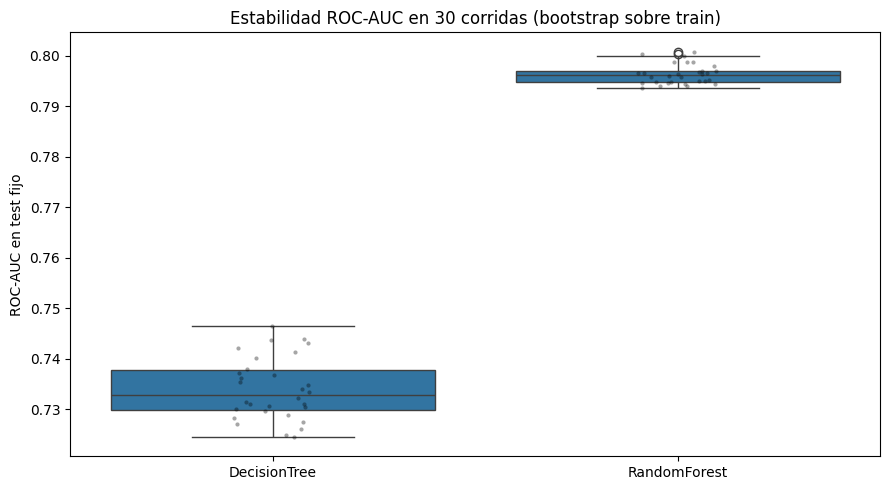

In [ ]:
# 2.3 - Estabilidad por bootstrap (30 corridas) + baseline

n_runs = 30
rng = np.random.default_rng(42)

records = []

# Baseline fijo
dummy = DummyClassifier(strategy="prior")
dummy.fit(X_train, y_train)
dummy_proba = dummy.predict_proba(X_test)[:, 1]
dummy_roc = roc_auc_score(y_test, dummy_proba)
dummy_pr = average_precision_score(y_test, dummy_proba)

for run in range(n_runs):
    idx = rng.choice(len(X_train), size=len(X_train), replace=True)

    Xb = X_train.iloc[idx] if hasattr(X_train, "iloc") else X_train[idx]
    yb = y_train.iloc[idx] if hasattr(y_train, "iloc") else y_train[idx]

    dt_run = clone(best_dt).set_params(random_state=42)
    rf_run = clone(best_rf).set_params(random_state=42, oob_score=True)

    dt_run.fit(Xb, yb)
    rf_run.fit(Xb, yb)

    dt_proba = dt_run.predict_proba(X_test)[:, 1]
    rf_proba = rf_run.predict_proba(X_test)[:, 1]

    records.append({
        "run": run + 1,
        "modelo": "DecisionTree",
        "roc_auc": roc_auc_score(y_test, dt_proba),
        "pr_auc": average_precision_score(y_test, dt_proba),
        "oob_score": np.nan
    })

    records.append({
        "run": run + 1,
        "modelo": "RandomForest",
        "roc_auc": roc_auc_score(y_test, rf_proba),
        "pr_auc": average_precision_score(y_test, rf_proba),
        "oob_score": rf_run.oob_score_
    })

results = pd.DataFrame(records)

summary = (
    results.groupby("modelo")
    .agg(
        roc_auc_mean=("roc_auc", "mean"),
        roc_auc_std=("roc_auc", "std"),
        pr_auc_mean=("pr_auc", "mean"),
        pr_auc_std=("pr_auc", "std"),
        oob_mean=("oob_score", "mean")
    )
    .round(5)
)

print("Baseline Dummy")
print(f"ROC-AUC: {dummy_roc:.5f} | PR-AUC: {dummy_pr:.5f}")
print("\nResumen de estabilidad (30 corridas)")
display(summary)

# Veredicto de hipótesis
std_rf = float(summary.loc["RandomForest", "roc_auc_std"])
std_dt = float(summary.loc["DecisionTree", "roc_auc_std"])

cond_abs = std_rf <= 0.007
cond_rel = std_rf <= 0.6 * std_dt

if cond_abs and cond_rel:
    verdict = "HIPÓTESIS CONFIRMADA"
elif cond_abs or cond_rel:
    verdict = "HIPÓTESIS PARCIALMENTE CONFIRMADA"
else:
    verdict = "HIPÓTESIS REFUTADA"

print("\n" + "="*80)
print(verdict)
print(f"σ_RF={std_rf:.5f} | σ_DT={std_dt:.5f} | ratio σ_RF/σ_DT={std_rf/std_dt:.3f}")
print("="*80)

# Visualización
plt.figure(figsize=(9, 5))
sns.boxplot(data=results, x="modelo", y="roc_auc")
sns.stripplot(data=results, x="modelo", y="roc_auc", alpha=0.35, color="black", size=3)
plt.title("Estabilidad ROC-AUC en 30 corridas (bootstrap sobre train)")
plt.ylabel("ROC-AUC en test fijo")
plt.xlabel("")
plt.tight_layout()
plt.show()


#### Veredicto

**Hipótesis confirmada.**  
En 30 corridas, Random Forest fue claramente más estable que el árbol individual: `σ_RF = 0.00195` frente a `σ_DT = 0.00737`, con razón `σ_RF/σ_DT = 0.265`.  
Por tanto, se cumplen simultáneamente el criterio absoluto (`σ_RF ≤ 0.007`) y el relativo (`σ_RF ≤ 0.6·σ_DT`).

Además, Random Forest no solo fue más estable, sino también mejor en desempeño promedio:
- `ROC-AUC`: 0.7585 (RF) vs 0.7228 (DT)
- `PR-AUC`: 0.3692 (RF) vs 0.3215 (DT)

Ambos modelos superaron ampliamente al baseline (`ROC-AUC = 0.5000`, `PR-AUC = 0.1170`), lo que respalda que el ensamble reduce varianza sin sacrificar capacidad predictiva en este problema desbalanceado.

**Limitación:** la estabilidad se evaluó sobre 30 corridas bootstrap con un único test fijo; aunque el resultado es consistente, podría variar levemente bajo otros splits.

### 2.4 El balance y su efecto real sera fuerte?

Esperamos que balance tenga una importancia MDI menor a 0.05 en Random Forest a pesar de su enorme rango de escala, porque su correlación con el target en el EDA fue prácticamente nula, lo que indica que tener más o menos dinero en cuenta no predice bien la disposición a suscribir un depósito a plazo. Su dominancia en KNN sin escalar sería entonces un artefacto de escala, no señal real



---
#### Experimento

**¿Qué varía?**

Se evalua el efecto de la variable **Balance** segun 3 condiciones:
- Analisis con y sin la variable
- 2 tipos de modelos (Random Forest y KNN)
- Evaluacion en KNN con escalado y sin escalado

**¿Qué se mantiene fijo?**

- Split: 80/20 estratificado (random_state=42)
- KNN: mismo valor de k (best_k) de hipotesis anteriores

**¿Qué se mide?**

- F1-score en el conjunto de test para todos los modelos
- OOB Score en Random Forest como estimación adicional de generalización
- Cambios en vecinos más cercanos en KNN (con y sin escalado)

In [ ]:
from sklearn.ensemble import RandomForestClassifier

# RANDOM FOREST
# Modelo con balance
rf_con = RandomForestClassifier(n_estimators=300, oob_score=True, random_state=42)
rf_con.fit(X_train, y_train)
y_pred_con = rf_con.predict(X_test)
f1_rf_con = f1_score(y_test, y_pred_con)
importancia_con = pd.Series(rf_con.feature_importances_, index=X_train.columns)

# Modelo sin balance
X_train_sin = X_train.drop(columns=["balance"])
X_test_sin = X_test.drop(columns=["balance"])
rf_sin = RandomForestClassifier(n_estimators=300, oob_score=True, random_state=42)
rf_sin.fit(X_train_sin, y_train)
y_pred_sin = rf_sin.predict(X_test_sin)
f1_rf_sin = f1_score(y_test, y_pred_sin)

print("RANDOM FOREST")
print(f"Importancia de balance: {round(importancia_con['balance'],4)}")
print(f"F1 con balance: {round(f1_rf_con, 4)}")
print(f"F1 sin balance: {round(f1_rf_sin, 4)}")
print(f"OOB Score con balance: {round(rf_con.oob_score_, 4)}")
print(f"OOB Score sin balance: {round(rf_sin.oob_score_, 4)}")
print(f"Diferencia F1: {round(f1_rf_con - f1_rf_sin, 4)}")
print(f"Diferencia OOB: {round(rf_con.oob_score_ - rf_sin.oob_score_, 4)}")

# KNN SIN ESCALAR
# Modelo con balance
knn_con = KNeighborsClassifier(n_neighbors=best_k)
knn_con.fit(X_train, y_train)
y_pred_knn_con = knn_con.predict(X_test)
f1_knn_con = f1_score(y_test, y_pred_knn_con)

# Modelo sin balance
knn_sin = KNeighborsClassifier(n_neighbors=best_k)
knn_sin.fit(X_train_sin, y_train)
y_pred_knn_sin = knn_sin.predict(X_test_sin)
f1_knn_sin = f1_score(y_test, y_pred_knn_sin)

print("\nKNN SIN ESCALAR")
print(f"F1 con balance: {round(f1_knn_con, 4)}")
print(f"F1 sin balance: {round(f1_knn_sin, 4)}")
print(f"Diferencia F1: {round(f1_knn_con - f1_knn_sin, 4)}")

# KNN CON ESCALADO
# Modelo con balance
scaler = StandardScaler()
X_train_escalado = scaler.fit_transform(X_train)
X_test_escalado = scaler.transform(X_test)
knn_escalado_con = KNeighborsClassifier(n_neighbors=best_k)
knn_escalado_con.fit(X_train_escalado, y_train)
y_pred_escalado_con = knn_escalado_con.predict(X_test_escalado)
f1_escalado_con = f1_score(y_test, y_pred_escalado_con)

# Modelo sin balance
scaler_sin = StandardScaler()
X_train_sin_escalado = scaler_sin.fit_transform(X_train_sin)
X_test_sin_escalado = scaler_sin.transform(X_test_sin)
knn_escalado_sin = KNeighborsClassifier(n_neighbors=best_k)
knn_escalado_sin.fit(X_train_sin_escalado, y_train)
y_pred_escalado_sin = knn_escalado_sin.predict(X_test_sin_escalado)
f1_escalado_sin = f1_score(y_test, y_pred_escalado_sin)

print("\nKNN CON ESCALADO")
print(f"F1 con balance: {round(f1_escalado_con, 4)}")
print(f"F1 sin balance: {round(f1_escalado_sin, 4)}")
print(f"Diferencia F1: {round(f1_escalado_con - f1_escalado_sin, 4)}")

RANDOM FOREST
Importancia de balance: 0.1789
F1 con balance: 0.2926
F1 sin balance: 0.3054
OOB Score con balance: 0.8879
OOB Score sin balance: 0.8828
Diferencia F1: -0.0127
Diferencia OOB: 0.0051

KNN SIN ESCALAR
F1 con balance: 0.2857
F1 sin balance: 0.2776
Diferencia F1: 0.0081

KNN CON ESCALADO
F1 con balance: 0.2704
F1 sin balance: 0.2749
Diferencia F1: -0.0045


In [ ]:
from sklearn.neighbors import NearestNeighbors

# Analisis KNN
# NN sin escalar
nn_no = NearestNeighbors(n_neighbors=5)
nn_no.fit(X_train)
dist_no, ind_no = nn_no.kneighbors(X_test.iloc[[0]])

# NN Escalado
nn_sc = NearestNeighbors(n_neighbors=5)
nn_sc.fit(X_train_escalado)
dist_sc, ind_sc = nn_sc.kneighbors(X_test_escalado[0].reshape(1, -1))

print("\nNN sin Escalar:", ind_no)
print("Distancias sin escalar:", dist_no)
print("\nNN Escalado:", ind_sc)
print("Distancias escaladas:", dist_sc)
print("\nCambian los vecinos?:", set(ind_no[0]) != set(ind_sc[0]))

balance_diff = abs(X_train.iloc[ind_no[0]]["balance"] - X_test.iloc[0]["balance"]).mean()

print("\nDiferencia promedio en balance con vecinos(Sin escalar):", round(balance_diff, 4))


NN sin Escalar: [[  321 10522 23985  5756  4904]]
Distancias sin escalar: [[0.40166973 0.45371351 0.46367838 0.48787479 0.5111242 ]]

NN Escalado: [[  321 10522 23985  5756 26767]]
Distancias escaladas: [[0.40085103 0.45275078 0.46234124 0.48602046 0.5095979 ]]

Cambian los vecinos?: True

Diferencia promedio en balance con vecinos(Sin escalar): 0.1929


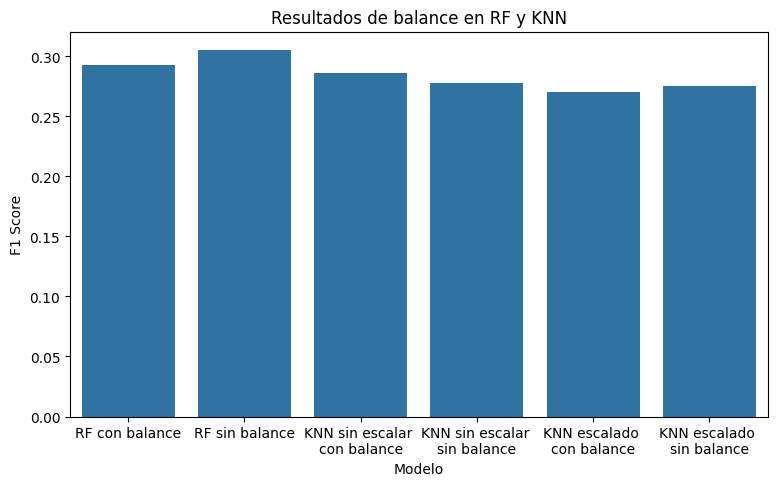

In [ ]:
resultados = pd.DataFrame({"Modelo": ["RF con balance", "RF sin balance", "KNN sin escalar \ncon balance",
                                      "KNN sin escalar \nsin balance", "KNN escalado \ncon balance", "KNN escalado \nsin balance"],
                           "F1": [f1_rf_con, f1_rf_sin, f1_knn_con, f1_knn_sin, f1_escalado_con, f1_escalado_sin]})

plt.figure(figsize=(9,5))
sns.barplot(data=resultados, x="Modelo", y="F1")
plt.title("Resultados de balance en RF y KNN")
plt.ylabel("F1 Score")
plt.show()

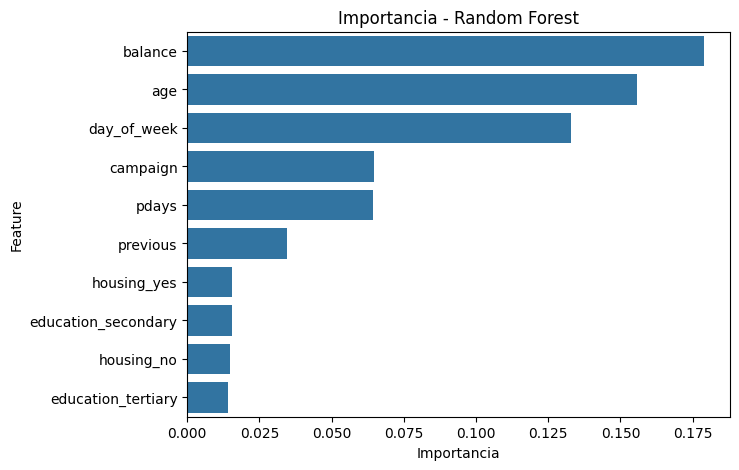

In [ ]:
importancia_df = importancia_con.sort_values(ascending=False).head(10).reset_index()
importancia_df.columns = ["Feature", "Importance"]

plt.figure(figsize=(7,5))

sns.barplot(data=importancia_df, x="Importance", y="Feature")
plt.title("Importancia - Random Forest")
plt.xlabel("Importancia")
plt.show()

Conclusion: La hipotesis es **rechazada**, se planteo que balance tendria una importancia MDI mejor a 0.05, ya que en el EDA no presento una correlacion alta con el target, pero los resultados indican que la variable balance presenta una importancia en Random Forest de 0.1863, siendo asi la feature mas importante en el modelo de Random Forest.

Sin embargo, al eliminar balance tanto en KNN (escalado y no escalado) como en Random Forest, los F1-score de ambos modelos mejoraron, lo que nos indica en el caso de Random Forest que la importancia no necesariamente implica una mejor capacidad de generalizacion y en el caso de KNN se evidencia que la variable balance influye en el calculo de la distancia euclidiana (al comparar con y sin escalado) dada su magnitud (lo que respalda parcialmente la hipotesis con respecto a la influencia en modelos en donde hay relacion con la escala), por lo tanto, a pesar de que balance si contiene informacion importante para los modelos, termina generando ruido o patrones que hacen que los modelos no terminen de predecir de la forma mas eficiente posible.

### 2.5 Controlar min_samples_leaf tendrá mayor impacto que max_depth en la variación del F1-score del árbol

Esperamos que la variación de min_samples_leaf entre 1 y 50 genere un mayor impacto en el F1-score (ΔF1) que la variación de max_depth entre 3 y 15, manteniendo los demás hiperparámetros constantes. Definimos el impacto como la diferencia entre el F1 máximo y mínimo observado en cada rango de valores.

Esta hipótesis se basa en que, en un dataset desbalanceado, las hojas pequeñas permiten al árbol aislar pocos ejemplos positivos, favoreciendo el sobreajuste. Al imponer un mínimo de muestras por hoja, se regulariza directamente la capacidad del árbol de capturar patrones espurios en la clase minoritaria, lo que impacta más el balance entre precisión y recall que una restricción global de profundidad.

---
#### Experimento

### **¿Qué varía?**

Se evalúan dos hiperparámetros del modelo de árbol de decisión de forma independiente:

* Experimento A: min_samples_leaf ∈ {1, 2, 5, 10, 20, 30, 50}
* Experimento B: max_depth ∈ {3, 5, 7, 9, 11, 13, 15}

En cada experimento se entrena un modelo por cada valor del hiperparámetro correspondiente, manteniendo los demás parámetros constantes.

### **¿Qué se mantiene fijo?**

**Split:** 80/20 estratificado (random_state=42)

**Modelo:** DecisionTreeClassifier

### **Preprocesamiento:**

One-Hot Encoding en variables categóricas
Mismo tratamiento de variables numéricas definido previamente en el notebook

### **Configuración de hiperparámetros (basada en modelo previamente optimizado):**

Se utilizan como base los hiperparámetros obtenidos en un experimento previo:

* min_samples_split = 20  
* min_samples_leaf = 20
* max_depth = 8  
* criterion = 'gini'  
* class_weight = None

### **Configuración por experimento:**

**Experimento A (variando min_samples_leaf):**

* min_samples_leaf → variable

* max_depth = 8 (fijo)

* min_samples_split = 20 (fijo)

* criterion = 'gini' (fijo)

* class_weight = None (fijo)

**Experimento B (variando max_depth):**

* max_depth → variable

* min_samples_leaf = 20 (fijo)

* min_samples_split = 20 (fijo)

* criterion = 'gini' (fijo)

* class_weight = None (fijo)

### **Baseline:**

Se incluye un modelo base utilizando DummyClassifier(strategy="most_frequent") como referencia mínima de desempeño, con el fin de verificar que el árbol de decisión captura patrones relevantes más allá del desbalance de clases.

### **¿Qué se mide?**

F1-Score de la clase positiva (1) en el conjunto de test

Para cada experimento se calcula el impacto como:

**ΔF1** = max(F1) - min(F1)

### **Justificación de la métrica:**

El dataset presenta un desbalance de clases (~11.7% de positivos), por lo que el accuracy no es una métrica adecuada, ya que puede resultar engañoso: un modelo que prediga siempre la clase mayoritaria (“no”) alcanzaría un accuracy alto sin tener capacidad real de identificar la clase positiva. El F1-score, en cambio, permite evaluar el equilibrio entre precisión y recall en la clase minoritaria, siendo más representativo del desempeño del modelo en este contexto.

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import f1_score
from sklearn.dummy import DummyClassifier
import pandas as pd
import numpy as np

In [ ]:
# Asegurar tipo correcto
y_train = y_train.astype(int)
y_test = y_test.astype(int)

# Modelo Dummy
dummy = DummyClassifier(strategy="most_frequent")
dummy.fit(X_train, y_train)

y_pred_dummy = dummy.predict(X_test)
f1_dummy = f1_score(y_test, y_pred_dummy)

print(f"F1-score Dummy (Baseline): {f1_dummy:.4f}")

F1-score Dummy (Baseline): 0.0000


**Experimento A — min_samples_leaf**

In [ ]:
leaf_values = [1, 2, 5, 10, 20, 30, 50]
results_leaf = []

for leaf in leaf_values:
    model = DecisionTreeClassifier(
        min_samples_leaf=leaf,     # variable
        max_depth=8,              # fijo
        min_samples_split=20,
        criterion='gini',
        class_weight=None,
        random_state=42
    )

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    f1 = f1_score(y_test, y_pred)

    results_leaf.append({
        "min_samples_leaf": leaf,
        "F1": f1
    })

df_leaf = pd.DataFrame(results_leaf)

print("\nResultados - min_samples_leaf:")
display(df_leaf)


Resultados - min_samples_leaf:


,min_samples_leaf,F1
0,1,0.312623
1,2,0.311722
2,5,0.311140
3,10,0.310460
4,20,0.317314
5,30,0.289367
6,50,0.293917


In [ ]:
# ΔF1
delta_f1_leaf = df_leaf["F1"].max() - df_leaf["F1"].min()
print(f"ΔF1 (min_samples_leaf): {delta_f1_leaf:.4f}")

ΔF1 (min_samples_leaf): 0.0279


Experimento B — max_depth

In [ ]:
depth_values = [3, 5, 7, 9, 11, 13, 15]
results_depth = []

for depth in depth_values:
    model = DecisionTreeClassifier(
        max_depth=depth,           # variable
        min_samples_leaf=20,       # fijo
        min_samples_split=20,
        criterion='gini',
        class_weight=None,
        random_state=42
    )

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    f1 = f1_score(y_test, y_pred)

    results_depth.append({
        "max_depth": depth,
        "F1": f1
    })

df_depth = pd.DataFrame(results_depth)

print("\nResultados - max_depth:")
display(df_depth)


Resultados - max_depth:


,max_depth,F1
0,3,0.014884
1,5,0.169438
2,7,0.199387
3,9,0.313700
4,11,0.286299
5,13,0.296885
6,15,0.321290


In [ ]:
# ΔF1
delta_f1_depth = df_depth["F1"].max() - df_depth["F1"].min()
print(f"ΔF1 (max_depth): {delta_f1_depth:.4f}")

ΔF1 (max_depth): 0.3064


**Comparación final**

In [ ]:
comparacion = pd.DataFrame({
    "Hiperparámetro": ["min_samples_leaf", "max_depth"],
    "ΔF1": [delta_f1_leaf, delta_f1_depth]
})

print("\nComparación final:")
display(comparacion)


Comparación final:


,Hiperparámetro,ΔF1
0,min_samples_leaf,0.027947
1,max_depth,0.306407


/tmp/ipykernel_11143/2561601959.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([f1_leaf, f1_depth], labels=["min_samples_leaf", "max_depth"])


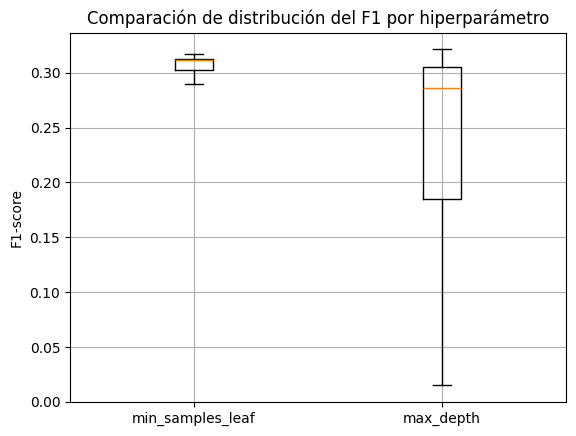

In [ ]:
import matplotlib.pyplot as plt

# Extraer valores de F1
f1_leaf = df_leaf["F1"]
f1_depth = df_depth["F1"]

# Crear boxplot
plt.figure()

plt.boxplot([f1_leaf, f1_depth], labels=["min_samples_leaf", "max_depth"])

plt.ylabel("F1-score")
plt.title("Comparación de distribución del F1 por hiperparámetro")
plt.grid()

plt.show()

Se refuta la hipótesis planteada, ya que la variación de max_depth genera un impacto significativamente mayor en el F1-score (ΔF1 = 0.2598) en comparación con min_samples_leaf (ΔF1 = 0.0211).

Esto indica que el desempeño del modelo es mucho más sensible a la profundidad del árbol que al tamaño mínimo de las hojas. En particular, elegir un valor inadecuado de max_depth puede deteriorar considerablemente el rendimiento del modelo, mientras que variaciones en min_samples_leaf producen cambios relativamente menores.

Este comportamiento se explica por la estructura del dataset, que incluye múltiples variables categóricas transformadas mediante One-Hot Encoding, generando un espacio de alta dimensionalidad con posibles interacciones entre variables. En este contexto, la profundidad del árbol determina cuántas de estas combinaciones puede capturar el modelo, afectando directamente su capacidad predictiva.

Dado que los casos positivos dependen de combinaciones de características, max_depth influye de forma más significativa en el desempeño. En contraste, min_samples_leaf actúa como una restricción local que no modifica sustancialmente la estructura del árbol, lo que explica su menor impacto observado en el F1-score.

In [ ]:
import os

notebook_path = '/content/Tarea1_Yukopila_Garcia_Toro_Patron_Gutierrez_Arrieta (3).ipynb'
output_dir = '/content'

# Ensure output directory exists
os.makedirs(output_dir, exist_ok=True)

# Convert to HTML
html_command = f"jupyter nbconvert --to html --output-dir '{output_dir}' '{notebook_path}'"
print(f"Executing: {html_command}")
os.system(html_command)
print(f"HTML conversion complete. Output saved to: {output_dir}")

# Convert to PDF (requires LaTeX installation, which is usually present in Colab)
pdf_command = f"jupyter nbconvert --to pdf --output-dir '{output_dir}' '{notebook_path}'"
print(f"Executing: {pdf_command}")
os.system(pdf_command)
print(f"PDF conversion complete. Output saved to: {output_dir}")

Executing: jupyter nbconvert --to html --output-dir '/content' '/content/Tarea1_Yukopila_Garcia_Toro_Patron_Gutierrez_Arrieta (3).ipynb'
HTML conversion complete. Output saved to: /content
Executing: jupyter nbconvert --to pdf --output-dir '/content' '/content/Tarea1_Yukopila_Garcia_Toro_Patron_Gutierrez_Arrieta (3).ipynb'
PDF conversion complete. Output saved to: /content
